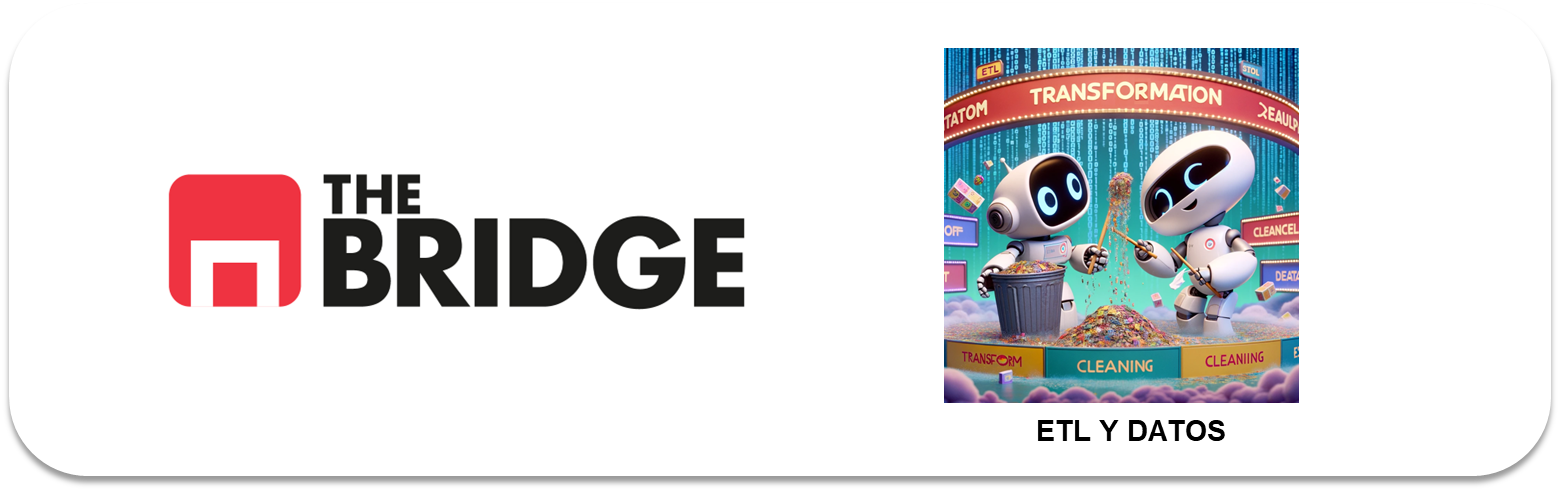

## ACCESO LOCAL: XML (I)
El formato **XML** (eXtensible Markup Language) es parecido al HTML, pero es más estructurado y es un tipo de formato de fichero que tiene cierto uso, y a diferencia del json, es más probable que encuentres datos que te interesen en este formato. [Ojo que eso no le quita importancia al Json]. 


### Estructura de un archivo XML



<img src="https://docs.adaptive-vision.com/current/studio/img/manual/XmlDescription.png">

 Además de lo visto para el ejemplo de arriba sobre etiquetas, una forma de ver los archivos XML es como si formasen un estructura de arbol en el que van apareciendo conjuntos de valores que pertenencen a otros conjuntos de valores a partir de un nodo raíz:

![Captura de pantalla 2026-05-16 133002.png](<attachment:Captura de pantalla 2026-05-16 133002.png>)
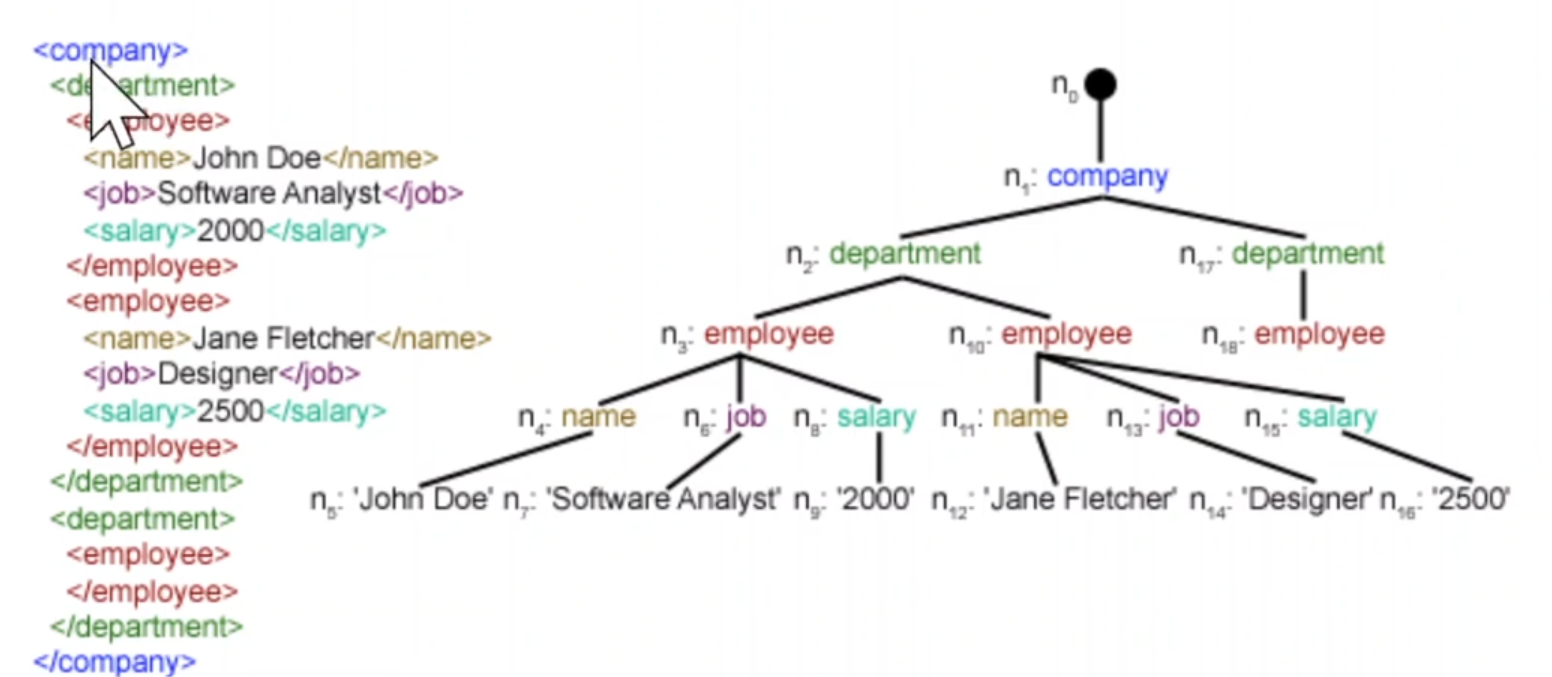

### Lectura de ficheros XML

Antes de utilizar la correspondiente librería de python (ojo esta no se llama `xml`) que nos ayude a procesar un fichero XML y extraer la información que pueda contener, veamos uno como texto plano que es:

In [1]:
with open("./data/cd_catalog.xml","r") as f:
    for line in f:
        print(line, end = "")

<?xml version="1.0" encoding="UTF-8"?>
<CATALOG>
  <CD id="1">
    <TITLE>Empire Burlesque</TITLE>
    <ARTIST>Bob Dylan</ARTIST>
    <COUNTRY>USA</COUNTRY>
    <COMPANY>Columbia</COMPANY>
    <PRICE>10.90</PRICE>
    <YEAR>1985</YEAR>
  </CD>
  <CD id="2">
    <TITLE>Hide your heart</TITLE>
    <ARTIST>Bonnie Tyler</ARTIST>
    <COUNTRY>UK</COUNTRY>
    <COMPANY>CBS Records</COMPANY>
    <PRICE>9.90</PRICE>
    <YEAR>1988</YEAR>
  </CD>
  <CD id="3">
    <TITLE>Greatest Hits</TITLE>
    <ARTIST>Dolly Parton</ARTIST>
    <COUNTRY>USA</COUNTRY>
    <COMPANY>RCA</COMPANY>
    <PRICE>9.90</PRICE>
    <YEAR>1982</YEAR>
  </CD>
  <CD id="4">
    <TITLE>Still got the blues</TITLE>
    <ARTIST>Gary Moore</ARTIST>
    <COUNTRY>UK</COUNTRY>
    <COMPANY>Virgin records</COMPANY>
    <PRICE>10.20</PRICE>
    <YEAR>1990</YEAR>
  </CD>
  <CD id="5">
    <TITLE>Eros</TITLE>
    <ARTIST>Eros Ramazzotti</ARTIST>
    <COUNTRY>EU</COUNTRY>
    <COMPANY>BMG</COMPANY>
    <PRICE>9.90</PRICE>
    <YEAR>199

Y si hacemos un pequeño ejercicio de interpretar las etiquetas llegaríamos a un árbol como este:

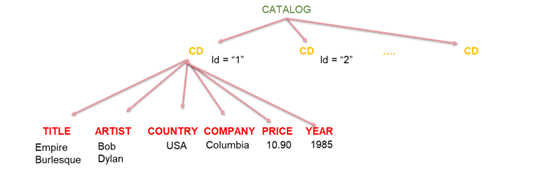

Lo que podría interesarnos es sacar los datos por CD para construirnos una tabla Catalog y ahí poner una fila por cd con su identificador (que podría ser nuestro índice de `DataFrame` por ejemplo) y los valores de cada una de esas etiquetas (TITLE, ARTIST, etc) las columnas... ¿Y cómo hacerlo?

Lo vamos a hacer con ayuda de la librería `ElementTree`:

In [2]:
import xml.etree.ElementTree as ET

Lo primero es leer y parsear el fichero de esta forma:


In [3]:
tree = ET.parse("./data/cd_catalog.xml")

### Procesando un fichero XML

Esta librería trata el XML como si fuese un árbol. En este formato de árbol, disponemos de diversos métodos con los que podemos extraer partes del XML. 

* `tag` muestra el texto dentro de la etiqueta
* `attrib` muestra los atributos de la etiqueta
* `text` muestra el texto del nodo
* La función `iter()` permite conocer la estructura del XML
* La función `find()` busca en el XML y devuelve el elemento que coincide con la etiqueta especificada.  
* La función `findall()` devuelve todos los elementos con cierta etiqueta

Una vez cargado juguemos con los métodos anteriores para obtener la información o los datos útiles de nuestro catálogo de CDs:

In [7]:
# Obtener la etiqueta del nodo raiz:
raiz = tree.getroot()
raiz.tag

'CATALOG'

Bien, poco hemos avanzado, porque esto ya lo intuíamos, vamos más allá y capturemos para cada elemento el nombre de sus etiquetas (aquí sólo tenemos CD como elemento, en el caso de la figura anterior teníamos DEPARTMENT, EMPLOYEE)

In [8]:
# Para cada elemento sus etiquetas
for elemento in raiz.iter():
    print(elemento.tag)

CATALOG
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD
TITLE
ARTIST
COUNTRY
COMPANY
PRICE
YEAR
CD


Esto lo aplana un poco y nos dice mucho sobre la jerarquía pero podemos ver jugar un poco para ver la estructura de forma más jerarquica además de ver los atributos y los valores (si hubiera unos u otros):

In [11]:
# Recorrido con cierta jerarquia
for hijo in raiz:
    tabs = "\t"
    print(hijo.tag, hijo.attrib)

CD {'id': '1'}
CD {'id': '2'}
CD {'id': '3'}
CD {'id': '4'}
CD {'id': '5'}
CD {'id': '6'}
CD {'id': '7'}
CD {'id': '8'}
CD {'id': '9'}
CD {'id': '10'}
CD {'id': '11'}
CD {'id': '12'}
CD {'id': '13'}
CD {'id': '14'}
CD {'id': '15'}
CD {'id': '16'}
CD {'id': '17'}
CD {'id': '18'}
CD {'id': '19'}
CD {'id': '20'}
CD {'id': '21'}
CD {'id': '22'}
CD {'id': '23'}
CD {'id': '24'}
CD {'id': '25'}
CD {'id': '99'}


In [12]:
for hijo in raiz:
    tabs = "\t"
    print(hijo.tag, hijo.attrib)
    for nieto in hijo:
        print(tabs, nieto.tag,nieto.text)

CD {'id': '1'}
	 TITLE Empire Burlesque
	 ARTIST Bob Dylan
	 COUNTRY USA
	 COMPANY Columbia
	 PRICE 10.90
	 YEAR 1985
CD {'id': '2'}
	 TITLE Hide your heart
	 ARTIST Bonnie Tyler
	 COUNTRY UK
	 COMPANY CBS Records
	 PRICE 9.90
	 YEAR 1988
CD {'id': '3'}
	 TITLE Greatest Hits
	 ARTIST Dolly Parton
	 COUNTRY USA
	 COMPANY RCA
	 PRICE 9.90
	 YEAR 1982
CD {'id': '4'}
	 TITLE Still got the blues
	 ARTIST Gary Moore
	 COUNTRY UK
	 COMPANY Virgin records
	 PRICE 10.20
	 YEAR 1990
CD {'id': '5'}
	 TITLE Eros
	 ARTIST Eros Ramazzotti
	 COUNTRY EU
	 COMPANY BMG
	 PRICE 9.90
	 YEAR 1997
CD {'id': '6'}
	 TITLE One night only
	 ARTIST Bee Gees
	 COUNTRY UK
	 COMPANY Polydor
	 PRICE 10.90
	 YEAR 1998
CD {'id': '7'}
	 TITLE Sylvias Mother
	 ARTIST Dr.Hook
	 COUNTRY UK
	 COMPANY CBS
	 PRICE 8.10
	 YEAR 1973
CD {'id': '8'}
	 TITLE Maggie May
	 ARTIST Rod Stewart
	 COUNTRY UK
	 COMPANY Pickwick
	 PRICE 8.50
	 YEAR 1990
CD {'id': '9'}
	 TITLE Romanza
	 ARTIST Andrea Bocelli
	 COUNTRY EU
	 COMPANY Polydor

Además puedo buscar elementos por sus etiquetas y hacer lo anterior de otra forma

In [ ]:
cds = tree.findall("CD")
for cd in cds:
    print("Id:", cd.attrib["id"])
    print("Titulo:", cd.find("TITLE").text)
    print("Artista:", cd.find("ARTIST").text)

Id: 1
Titulo: Empire Burlesque
Artista: Bob Dylan
Id: 2
Titulo: Hide your heart
Artista: Bonnie Tyler
Id: 3
Titulo: Greatest Hits
Artista: Dolly Parton
Id: 4
Titulo: Still got the blues
Artista: Gary Moore
Id: 5
Titulo: Eros
Artista: Eros Ramazzotti
Id: 6
Titulo: One night only
Artista: Bee Gees
Id: 7
Titulo: Sylvias Mother
Artista: Dr.Hook
Id: 8
Titulo: Maggie May
Artista: Rod Stewart
Id: 9
Titulo: Romanza
Artista: Andrea Bocelli
Id: 10
Titulo: When a man loves a woman
Artista: Percy Sledge
Id: 11
Titulo: Black angel
Artista: Savage Rose
Id: 12
Titulo: 1999 Grammy Nominees
Artista: Many
Id: 13
Titulo: For the good times
Artista: Kenny Rogers
Id: 14
Titulo: Big Willie style
Artista: Will Smith
Id: 15
Titulo: Tupelo Honey
Artista: Van Morrison
Id: 16
Titulo: Soulsville
Artista: Jorn Hoel
Id: 17
Titulo: The very best of
Artista: Cat Stevens
Id: 18
Titulo: Stop
Artista: Sam Brown
Id: 19
Titulo: Bridge of Spies
Artista: T'Pau
Id: 20
Titulo: Private Dancer
Artista: Tina Turner
Id: 21
Titulo

Usando cualquiera de las dos formas anteriores podría recorrer el XML y crear una estructura con la que luego obtener un `DataFrame`, pero eso lo veremos en la siguiente sesión.